In [2]:
import pandas as pd

# Load the two metadata files (real songs and fake songs)
fake = pd.read_csv("data/fake_songs.csv", low_memory=False)

real = pd.read_csv("data/real_songs.csv", low_memory=False)

print("Fake (AI) songs:", fake.shape)
print("Real (human) songs:", real.shape)

Fake (AI) songs: (49074, 17)
Real (human) songs: (48090, 13)


In [3]:
# Take a look at all the colummns for both
print("Fake (AI) columns:")
print(list(fake.columns))

print("\nReal (human) columns:")
print(list(real.columns))

Fake (AI) columns:
['id', 'lyrics', 'algorithm', 'style', 'filename', 'bit_rate', 'duration', 'source', 'lyrics_feature', 'topic', 'genre', 'mood', 'label', 'target', 'skip_time', 'no_vocal', 'split']

Real (human) columns:
['filename', 'title', 'artist', 'year', 'lyrics', 'duration', 'youtube_id', 'label', 'artist_overlap', 'target', 'skip_time', 'no_vocal', 'split']


In [4]:
from IPython.display import display

# Before I build the subset and start downloading audio I want to do a
# sanity check with the metadata to confirm what the columns I'll use actually are.
# Also to see what the unclear named columns are for (rather
# than guessing from their names).

# The columns I'll rely on later (filename, target, duration, algorithm,
# youtube_id) 
# Also the ones still unsure about (style, source,
# lyrics_feature, skip_time, artist_overlap):
fake_view = ["filename", "target", "duration", "algorithm",
             "style", "source", "lyrics_feature", "skip_time", "no_vocal"]

real_view = ["filename", "target", "duration", "youtube_id",
             "artist", "artist_overlap", "skip_time", "no_vocal"]


# Show the first 5 rows of just those columns as a readable table:
print("Fake (AI) — first 5 rows:")
display(fake[fake_view].head())

print("\nReal (human) — first 5 rows:")
display(real[real_view].head())

Fake (AI) — first 5 rows:


,filename,target,duration,algorithm,style,source,lyrics_feature,skip_time,no_vocal
0,fake_54113_suno_0,1,239.076,chirp-v3.5,"male vocals, lounge, piano, saxophone, slow te...",suno,* subject_matter: “The song reflects on the jo...,5.684094,False
1,fake_53851_suno_0,1,207.360,chirp-v3.5,"female vocals, salsa, piano, trumpet, percussi...",suno,* subject_matter: “The song tells the story of...,6.865344,False
2,fake_53851_suno_1,1,230.184,chirp-v3.5,"female vocals, salsa, piano, trumpet, percussi...",suno,* subject_matter: “The song tells the story of...,15.674094,False
3,fake_53853_suno_0,1,120.096,chirp-v3,"male vocals, guitar, drums, bass, grunge, mode...",suno,* subject_matter: “The song is about a person'...,0.030969,False
4,fake_53853_suno_1,1,120.096,chirp-v3,"male vocals, guitar, drums, bass, grunge, mode...",suno,* subject_matter: “The song is about a person'...,3.220344,False



Real (human) — first 5 rows:


,filename,target,duration,youtube_id,artist,artist_overlap,skip_time,no_vocal
0,real_00000,0,240.084,EZ-yNVc9Htw,Eminem,NaN,2.545344,False
1,real_00001,0,240.084,JGwWNGJdvx8,Ed Sheeran,NaN,15.876594,False
2,real_00002,0,177.084,ov4WobPqoSA,Kendrick Lamar,NaN,4.047219,False
3,real_00003,0,240.084,G5XpJP7f_SE,The Weeknd,NaN,3.524094,False
4,real_00004,0,240.084,_nxrYwT0SIo,Queen,True,4.857219,False


In [5]:
# Build a balanced subset with 2,000 AI and 2,000 human tracks
# A fixed random_state means we get the same sample every time it runs
# which keeps the project reproducible (NFR-002).

N = 2000
SEED = 42

fake_sample = fake.sample(n=N, random_state = SEED)

real_sample = real.sample(n=N, random_state = SEED)

print("AI sample:", fake_sample.shape)

print("Human sample:", real_sample.shape)


AI sample: (2000, 17)
Human sample: (2000, 13)


In [6]:
# Combine the two samples into one labelled dataset (4000 tracks)
subset = pd.concat([fake_sample, real_sample], ignore_index = True)

print("Combined subset:", subset.shape)

print(subset["target"].value_counts())

Combined subset: (4000, 22)
target
1    2000
0    2000
Name: count, dtype: int64


In [7]:
# Check the grouping with the artist aware split will use to prevent any leakage
# (Reals grouped by artist. Fakes by source song id)

print("Real (human) sample:")

print("unique artists:", real_sample["artist"].nunique())

print("most songs by one artist:")

print(real_sample["artist"].value_counts().head())

# fakes
print("\nFake (AI) sample:")

print("unique source ids:", fake_sample["id"].nunique())

print("most generations from one id:")

print(fake_sample["id"].value_counts().head())


Real (human) sample:
unique artists: 1468
most songs by one artist:
artist
Eminem                  7
The Weeknd              6
Kevin Gates             6
Florida Georgia Line    6
Panic! at the Disco     5
Name: count, dtype: int64

Fake (AI) sample:
unique source ids: 1963
most generations from one id:
id
17763    2
2955     2
31669    2
12576    2
16843    2
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import GroupShuffleSplit

# This will split it at 80/10/10 while keeping whole groups together
# no group is ever spread across two splits to avoid data leakage
def group_split_80_10_10(df, group_col, seed = 42):

    # 1) Take 80% as training and 20% as a temporary leftover split by group
    gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state = seed)

    train_idx, temp_idx = next(gss.split(df, groups = df[group_col]))

    train = df.iloc[train_idx]

    temp  = df.iloc[temp_idx]

    # 2) Half that leftover 20% into validation and test set roughyly 10%/10% overall
    gss2 = GroupShuffleSplit(n_splits = 1, train_size = 0.5, random_state = seed)

    val_idx, test_idx = next(gss2.split(temp, groups = temp[group_col]))

    val  = temp.iloc[val_idx]

    test = temp.iloc[test_idx]

    return train, val, test

# Apply to the human tracks grouping by artist
real_train, real_val, real_test = group_split_80_10_10(real_sample, "artist", seed = SEED)

print("Human tracks:")

print("train:", real_train.shape[0])

print("val:  ", real_val.shape[0])

print("test: ", real_test.shape[0])

Human tracks:
train: 1604
val:   204
test:  192


In [9]:
# using the the same function as above to the AI tracks grouping them by source song id
fake_train, fake_val, fake_test = group_split_80_10_10(fake_sample, "id", seed = SEED)

print("AI tracks:")

print("train:", fake_train.shape[0])

print("val:  ", fake_val.shape[0])

print("test: ", fake_test.shape[0])

AI tracks:
train: 1599
val:   199
test:  202


In [10]:
# Combine the AI and human splits so that each set has both classes
train = pd.concat([fake_train, real_train], ignore_index = True)

val   = pd.concat([fake_val,   real_val],   ignore_index = True)

test  = pd.concat([fake_test,  real_test],  ignore_index = True)

print("train:", train.shape)

print(train["target"].value_counts())

print("\nval:", val.shape)

print(val["target"].value_counts())

print("\ntest:", test.shape)

print(test["target"].value_counts())

train: (3203, 22)
target
0    1604
1    1599
Name: count, dtype: int64

val: (403, 22)
target
0    204
1    199
Name: count, dtype: int64

test: (394, 22)
target
1    202
0    192
Name: count, dtype: int64


In [11]:
# now need to verify that the split is leakage free so creating function
# so no artist (reals) and no source song id (fakes) appears in more than one split

def shared_groups(a, b, col):

    # this is to see if any group values appear in both dataframes
    return len(set(a[col]) & set(b[col]))

print("Real artists shared between splits (want 0 everywhere):")

print("train & val: ", shared_groups(real_train, real_val, "artist"))

print("train & test:", shared_groups(real_train, real_test, "artist"))

print("val & test:  ", shared_groups(real_val,   real_test, "artist"))


print("\nFake source ids shared between splits (want 0 everywhere):")

print("train & val: ", shared_groups(fake_train, fake_val, "id"))

print("train & test:", shared_groups(fake_train, fake_test, "id"))

print("val & test:  ", shared_groups(fake_val, fake_test, "id"))

Real artists shared between splits (want 0 everywhere):
train & val:  0
train & test: 0
val & test:   0

Fake source ids shared between splits (want 0 everywhere):
train & val:  0
train & test: 0
val & test:   0


In [ ]:
# now need to save it to disk so I don't have to rerun it each time
import os

# Label each set with its split name
# (this overwrites the datasets own split column which we're not using)
train["split"] = "train"
val["split"]   = "val"
test["split"]  = "test"

# Stack the three back into one table now carrying a split label per row
splits = pd.concat([train, val, test], ignore_index = True)

# Write it out as a CSV file
os.makedirs("data", exist_ok = True)

splits.to_csv("data/subset_splits.csv", index = False)

print("Saved:", splits.shape, "to data/subset_splits.csv")

print(splits["split"].value_counts())

Saved: (4000, 22) to data/subset_splits.csv
split
train    3203
val       403
test      394
Name: count, dtype: int64


In [ ]:
# explore the SONICS repos file layout on HuggingFace to count files, list folders and see how the audio is packaged

from huggingface_hub import list_repo_files # get huggingface function for listing the repos files

files = list_repo_files(repo_id="awsaf49/sonics", repo_type="dataset") # get a list of every file in the SONICS dataset repo

print("Total files:", len(files)) # prints total number of files

print("\nTop-level folders:")

for x in sorted(set(f.split("/")[0] for f in files)): # for each file take the top folder name. set() drops duplicates and sorted makes it alphabetical order
    print(" ", x)


print("\nFiles containing '44156':")
for f in files: # this loop is to go through every file path in the list and if a path has 44156 in it print it (44156 just an arbitrary number here as this is just for a test)

    if "44156" in f:

        print(" ", f)

print("\nFirst few .mp3 files:")

c = 0 # sets a counter

for f in files:

    if f.endswith(".mp3"): # this loop just makes it print the first 5 mp3 files and then stops (note nothing prints as they are all in zip files)

        print(" ", f); c += 1

        if c >= 5: break
        
print("\nAny .zip or .tar archives:") # same thing here but for zip and tar files
for f in files:

    if f.endswith(".zip") or ".tar" in f:

        print(" ", f)

Total files: 18

Top-level folders:
  .gitattributes
  README.md
  fake_songs
  fake_songs.csv
  metadata.json
  real_songs.csv
  test.csv
  train.csv
  valid.csv

Files containing '44156':

First few .mp3 files:

Any .zip or .tar archives:
  fake_songs/part_01.zip
  fake_songs/part_02.zip
  fake_songs/part_03.zip
  fake_songs/part_04.zip
  fake_songs/part_05.zip
  fake_songs/part_06.zip
  fake_songs/part_07.zip
  fake_songs/part_08.zip
  fake_songs/part_09.zip
  fake_songs/part_10.zip


In [ ]:
# check the total download size of the fake_songs zip parts before downloading them

# bring in HuggingFaces HfApi class (a blueprint for an API object)
from huggingface_hub import HfApi

api = HfApi() # build an HfApi object to talk to HuggingFace with

# ask HuggingFace for full info on the SONICS repo including file sizes (files_metadata=True)
info = api.repo_info(repo_id="awsaf49/sonics", repo_type="dataset", files_metadata=True)

print("All files in fake_songs/ with sizes:")

total = 0

# go through every file in the repo
for f in info.siblings:

    if f.rfilename.startswith("fake_songs/"): # this makes it get only the zips

        size_mb = (f.size or 0) / (1024*1024) # converts the bytes to MB (or zero if size is missing)

        total += size_mb # add to total
        
        print(f"  {f.rfilename}  —  {size_mb:.1f} MB") # print the files name and size to 1 decimal place


#print(f"\nTotal size of all fake_songs zips: {total:.1f} MB ({total/1024:.1f} GB)") # prints the grand total of all the fake zip files and shows in MB and GB

All files in fake_songs/ with sizes:
  fake_songs/part_01.zip  —  3612.1 MB
  fake_songs/part_02.zip  —  3404.5 MB
  fake_songs/part_03.zip  —  3003.3 MB
  fake_songs/part_04.zip  —  2979.2 MB
  fake_songs/part_05.zip  —  3058.2 MB
  fake_songs/part_06.zip  —  3041.7 MB
  fake_songs/part_07.zip  —  3007.9 MB
  fake_songs/part_08.zip  —  2996.2 MB
  fake_songs/part_09.zip  —  3023.2 MB
  fake_songs/part_10.zip  —  2577.7 MB

Total size of all fake_songs zips: 30704.0 MB (30.0 GB)


In [ ]:
# load one real audio track into memory (waveform y + sample rate sr) to test the spectrogram pipeline on
import librosa

# pick one real track to test with
test_file = "data/audio/real" # this is the folder that the track will be grabbed from

# list whats in there and grab the first file
import os

files = os.listdir(test_file)

print("Number of files in real folder:", len(files)) # number of files in the folder

print("First file:", files[0]) # grabs the first one

# load that one audio file
first_path = os.path.join(test_file, files[0]) # this creates one complete path to the file

y, sr = librosa.load(first_path) # y is the waveform (audio as numbers) and sr is the sample rate (samples per second) (22050 by default)

print("\nLoaded successfully!")

# y.shape = how many samples are in the waveform e.g. (3745325, ) means 3745325 samples
# the "(this many samples)" text is just a label showing that number is a sample count
print("Audio data shape:", y.shape, "(this many samples)")

print("Sample rate:", sr, "(samples per second)") # sr = the sample rate i.e. how many samples make up one second of audio (22050 here)

print("Duration:", round(len(y) / sr, 1), "seconds") # total duration in seconds rounded to 1 decimal place

Number of files in real folder: 1723
First file: real_00118.wav

Loaded successfully!
Audio data shape: (3745325,) (this many samples)
Sample rate: 22050 (samples per second)
Duration: 169.9 seconds


Mel-spectrogram shape: (128, 7316) (mel bands, time frames)


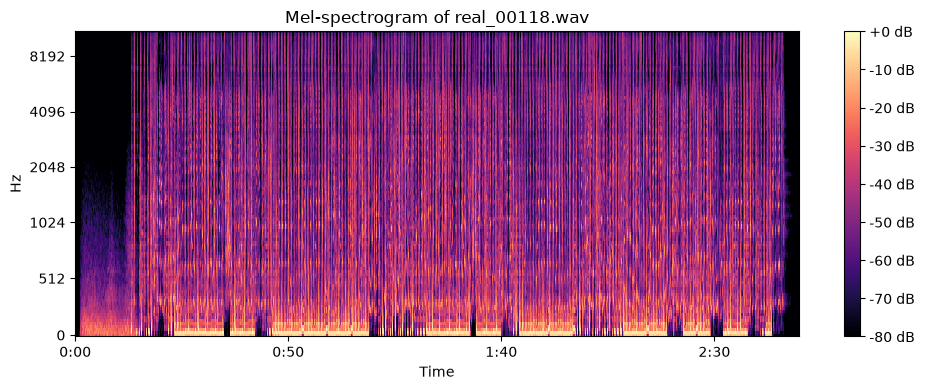

In [ ]:
# drawing out a mel-spectrogram for 1 real track just to see what it looks like

# tools for drawing out the mel-spectrogram. librosa.display to draw spectrogram. matplotlib.pyplot for plotting. numpy for the dB
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. make the mel-spectrogram from the audio (y, sr from before)
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

# 2. convert to decibels (loudness on a log scale). The loudest point will be the 0 dB reference
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("Mel-spectrogram shape:", mel_spec_db.shape, "(mel bands, time frames)") # print grid size

# 3. draw it
plt.figure(figsize=(10, 4)) # blank canvas 10 x 4 inches

librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel") # draw the grid with these axes

plt.colorbar(format="%+2.0f dB") #colour scale legend for loudness in dB

plt.title("Mel-spectrogram of real_00118.wav") # title

plt.tight_layout() # tidies up the spacing so nothing overlaps

plt.show() # display mel-spectrogram

Number of fake files: 2000
First fake file: fake_00014_suno_1.mp3
Duration: 213.9 seconds


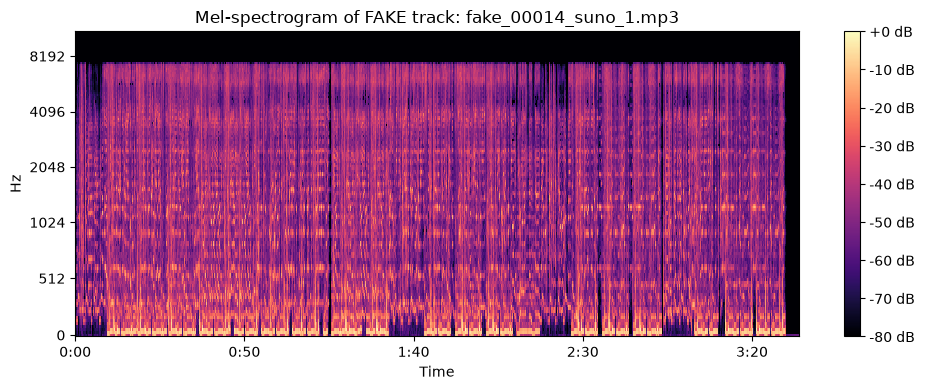

In [ ]:
# load and make a mel-spectrogram for one fake track to compare with the real one

fake_dir = "data/audio/fake" # this is the folder of the fake tracks

fake_files = os.listdir(fake_dir) # list all of the tracks in the folder

print("Number of fake files:", len(fake_files)) # print how many there are

print("First fake file:", fake_files[0]) # print the name of the first one

# load it. own variable names (y_fake/sr_fake) so the real y/sr from earlier aren't overwritten

fake_path = os.path.join(fake_dir, fake_files[0]) # creates full path to the first fake file

y_fake, sr_fake = librosa.load(fake_path) # y_fake = waveform, sr_fake = sample rate (22050)

print("Duration:", round(len(y_fake) / sr_fake, 1), "seconds") # length in seconds

# make the mel-spectrogram (same as real in previous cell.)
mel_fake = librosa.feature.melspectrogram(y=y_fake, sr=sr_fake, n_mels=128)

mel_fake_db = librosa.power_to_db(mel_fake, ref=np.max)

# draw it
plt.figure(figsize=(10, 4))

librosa.display.specshow(mel_fake_db, sr=sr_fake, x_axis="time", y_axis="mel")

plt.colorbar(format="%+2.0f dB")

plt.title(f"Mel-spectrogram of FAKE track: {fake_files[0]}")

plt.tight_layout()

plt.show()